Integrate all ML types

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

In [2]:
N = 1000

lux = np.random.normal(300, 50, N)
time = np.arange(N) % 24
occupancy = np.random.choice([0,1], N)
curtain = np.random.choice([0,1], N)

df = pd.DataFrame({
    "lux": lux,
    "time": time,
    "occupancy": occupancy,
    "curtain": curtain
})
df.tail()

,lux,time,occupancy,curtain
995,285.944985,11,1,0
996,389.884326,12,0,1
997,332.042143,13,1,0
998,271.441051,14,0,1
999,328.629139,15,0,0


In [3]:
df.describe()

,lux,time,occupancy,curtain
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,300.966603,11.436000,0.511000,0.52000
std,48.960797,6.913009,0.500129,0.49985
min,137.936633,0.000000,0.000000,0.00000
25%,267.620485,5.000000,0.000000,0.00000
50%,301.265031,11.000000,1.000000,1.00000
75%,332.397194,17.000000,1.000000,1.00000
max,492.636575,23.000000,1.000000,1.00000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lux        1000 non-null   float64
 1   time       1000 non-null   int64  
 2   occupancy  1000 non-null   int64  
 3   curtain    1000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 31.4 KB


In [5]:
df["lux_1"] = df["lux"].shift(1)
df["lux_2"] = df["lux"].shift(2)
df["lux_3"] = df["lux"].shift(3)

df = df.dropna().reset_index(drop=True)

ssl_features = ["lux_1","lux_2","lux_3"]

X_ssl = df[ssl_features]
y_ssl = df["lux"]

ssl_model = MLPRegressor(hidden_layer_sizes=(16,), max_iter=500)
ssl_model.fit(X_ssl, y_ssl)

df["lux_embedding"] = ssl_model.predict(X_ssl)

# ---- Evaluate SSL ----
ssl_mse = mean_squared_error(y_ssl, df["lux_embedding"])
print("Self-Supervised MSE:", ssl_mse)

Self-Supervised MSE: 3164.2472509332183


In [6]:
np.random.seed(40)
N = 1000
time = np.arange(N) % 24

# ---- Daylight sinusoidal model ----
A = 400
B = 100

daylight = A * np.sin((2*np.pi*time/24) - np.pi/2) + B
daylight = np.clip(daylight, 0, None)

# ---- Curtain behavior ----
curtain = np.where((time >= 8) & (time <= 18), 1, 0)

# Random toggling (10% randomness)
random_toggle = np.random.rand(N) < 0.1
curtain[random_toggle] = 1 - curtain[random_toggle]

# Curtain reduces light when closed (70% blocked)
lux_after_curtain = daylight * (0.3 + 0.7*curtain)

# Weather noise
noise = np.random.normal(0, 30, N)
lux = lux_after_curtain + noise
lux = np.clip(lux, 0, None)

# Occupancy pattern
occupancy = ((time >= 8) & (time <= 22)).astype(int)

df = pd.DataFrame({
    "time": time,
    "lux": lux,
    "occupancy": occupancy,
    "curtain": curtain
})

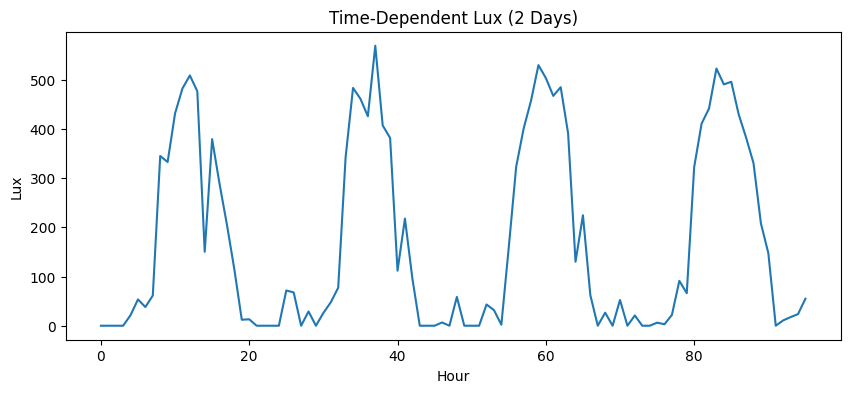

In [7]:
plt.figure(figsize=(10,4))
plt.plot(df["lux"][:96])
plt.title("Time-Dependent Lux (2 Days)")
plt.xlabel("Hour")
plt.ylabel("Lux")
plt.show()

In [8]:
df["lux_1"] = df["lux"].shift(1)
df["lux_2"] = df["lux"].shift(2)
df["lux_3"] = df["lux"].shift(3)

df = df.dropna().reset_index(drop=True)

In [9]:
df["time_sin"] = np.sin(2*np.pi*df["time"]/24)
df["time_cos"] = np.cos(2*np.pi*df["time"]/24)

ssl_features = ["lux_1","lux_2","lux_3","curtain","time_sin","time_cos"]

X_ssl = df[ssl_features]
y_ssl = df["lux"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_ssl)
y_scaled = scaler_y.fit_transform(y_ssl.values.reshape(-1,1)).ravel()

ssl_model = MLPRegressor(hidden_layer_sizes=(32,),
                         max_iter=2000,
                         learning_rate_init=0.001)

ssl_model.fit(X_scaled, y_scaled)

pred_scaled = ssl_model.predict(X_scaled)
pred = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).ravel()

df["lux_embedding"] = pred

ssl_mse = mean_squared_error(y_ssl, pred)
print("Self-Supervised MSE:", ssl_mse)

Self-Supervised MSE: 931.8807852145837


In [10]:
df["comfort"] = (
    (df["lux"] > 250) &
    (df["lux"] < 400) &
    (df["occupancy"] == 1)
).astype(int)
df.tail()

,time,lux,occupancy,curtain,lux_1,lux_2,lux_3,time_sin,time_cos,lux_embedding,comfort
992,11,75.975680,1,0,470.193735,373.451432,326.148213,2.588190e-01,-0.965926,189.967041,0
993,12,535.414447,1,1,75.975680,470.193735,373.451432,1.224647e-16,-1.000000,460.372197,0
994,13,532.830118,1,1,535.414447,75.975680,470.193735,-2.588190e-01,-0.965926,490.223934,0
995,14,438.417117,1,1,532.830118,535.414447,75.975680,-5.000000e-01,-0.866025,416.238585,0
996,15,132.746009,1,0,438.417117,532.830118,535.414447,-7.071068e-01,-0.707107,100.145930,0


In [11]:
comfort_features = ["lux_embedding","time","occupancy","curtain"]

np.random.seed(42)
mask = np.random.rand(len(df)) < 0.2
labeled = df[mask]
unlabeled = df[~mask]

X_lab = labeled[comfort_features]
y_lab = labeled["comfort"]

semi_model = LogisticRegression()
semi_model.fit(X_lab, y_lab)

initial_acc = accuracy_score(y_lab, semi_model.predict(X_lab))
print("Initial Accuracy:", initial_acc)

# Pseudo-label
X_unlab = unlabeled[comfort_features]
probs = semi_model.predict_proba(X_unlab)[:,1]

confidence = 0.9
selected = (probs > confidence) | (probs < 1-confidence)

pseudo = unlabeled[selected].copy()
pseudo["comfort"] = (probs[selected] > 0.5).astype(int)

combined = pd.concat([labeled, pseudo])
df = combined.copy()
print(df.describe())
semi_model.fit(combined[comfort_features],
               combined["comfort"])

expanded_acc = accuracy_score(
    combined["comfort"],
    semi_model.predict(combined[comfort_features])
)

print("Semi-Supervised Accuracy:", expanded_acc)

Initial Accuracy: 0.9017857142857143
             time         lux   occupancy     curtain       lux_1       lux_2  \
count  636.000000  636.000000  636.000000  636.000000  636.000000  636.000000   
mean    10.734277   72.584051    0.438679    0.157233   87.587496   96.656295   
std      7.934584  129.559642    0.496616    0.364307  149.192704  153.920649   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      4.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      8.000000   21.977357    0.000000    0.000000   22.013590   23.168909   
75%     19.000000   61.434547    1.000000    0.000000   72.360850  100.481570   
max     23.000000  539.884584    1.000000    1.000000  560.330796  565.041283   

            lux_3    time_sin    time_cos  lux_embedding     comfort  
count  636.000000  636.000000  636.000000     636.000000  636.000000  
mean   107.072197    0.102145    0.295081      73.996898    0.034591  
std    156.718615   

In [12]:
anomaly_model = IsolationForest(contamination=0.05)
anomaly_model.fit(df[["lux"]])

anomaly_rate = np.mean(anomaly_model.predict(df[["lux"]]) == -1)
print("Detected Anomaly Rate:", anomaly_rate)

Detected Anomaly Rate: 0.050314465408805034


In [13]:
class QAgent:
    def __init__(self):
        self.states = 20
        self.actions = [-20, 0, 20]
        self.Q = np.zeros((self.states, len(self.actions)))
        self.alpha = 0.1
        self.gamma = 0.99
        self.epsilon = 0.1

    def discretize(self, lux):
        return min(int(lux/30), self.states-1)

    def act(self, state):
        if random.random() < self.epsilon:
            return random.choice(range(len(self.actions)))
        return np.argmax(self.Q[state])

    def update(self, s, a, r, s2):
        self.Q[s,a] += self.alpha * (
            r + self.gamma*np.max(self.Q[s2]) - self.Q[s,a]
        )

agent = QAgent()

In [14]:
agent.epsilon = 0

In [15]:
np.random.seed(42)
def run_episode(controller_type, steps=500):

    lux_value = 200
    rewards = []

    for t in range(steps):

        hour = t % 24

        # --- Cloud disturbance ---
        cloud_factor = 1.0
        if np.random.rand() < 0.15:
            cloud_factor = np.random.uniform(0.2, 0.7)

        daylight = 400 * np.sin((2*np.pi*hour/24) - np.pi/2)
        daylight = max(daylight, 0)
        daylight *= cloud_factor

        # --- Curtain random ---
        if np.random.rand() < 0.1:
            curtain_now = np.random.choice([0,1])
        else:
            curtain_now = 1

        daylight *= (0.3 + 0.7*curtain_now)

        # --- Occupancy random ---
        occupancy_now = np.random.choice([0,1], p=[0.3,0.7])

        # --- SSL embedding ---
        lag_input = pd.DataFrame(
            [[lux_value,lux_value,lux_value,curtain_now,
              np.sin(2*np.pi*hour/24),
              np.cos(2*np.pi*hour/24)]],
            columns=ssl_features
        )

        lag_scaled = scaler_X.transform(lag_input)
        emb_scaled = ssl_model.predict(lag_scaled)
        emb = scaler_y.inverse_transform(
            emb_scaled.reshape(-1,1)
        ).ravel()[0]

        comfort_input = pd.DataFrame(
            [[emb, hour, occupancy_now, curtain_now]],
            columns=comfort_features
        )

        comfort_prob = semi_model.predict_proba(comfort_input)[0][1]

        anomaly_flag = anomaly_model.predict(
            pd.DataFrame([[lux_value]], columns=["lux"])
        )[0]

        anomaly_penalty = 1 if anomaly_flag == -1 else 0

        # --- Controller decision ---
        if controller_type == "RL":
            state = agent.discretize(lux_value)
            action = agent.actions[np.argmax(agent.Q[state])]
        else:
            # Rule-based
            if lux_value < 280:
                action = 20
            elif lux_value > 380:
                action = -20
            else:
                action = 0

        # --- Delayed dynamics ---
        lux_value = 0.8*lux_value + 0.2*(daylight + action)
        lux_value = np.clip(lux_value, 0, 600)

        energy_cost = lux_value * 0.01

        reward = (
            3*comfort_prob
            - energy_cost
            - 2*anomaly_penalty
        )

        rewards.append(reward)

    return np.mean(rewards)

In [16]:
episodes = 5
steps = 300

rl_scores = []
rule_scores = []

for _ in range(episodes):
    rl_scores.append(run_episode("RL"))
    rule_scores.append(run_episode("RULE"))

print("RL Avg Reward:", np.mean(rl_scores))
print("Rule Avg Reward:", np.mean(rule_scores))

print("RL Std:", np.std(rl_scores))
print("Rule Std:", np.std(rule_scores))

RL Avg Reward: -0.6361088544212307
Rule Avg Reward: -1.140195588618916
RL Std: 0.024218229835516983
Rule Std: 0.03369051836682058
